# 01. Exploratory Data Analysis: Thermoelectrical Dynamics of PMSM Drives

This notebook conducts a rigorous physical and statistical exploration of the Permanent Magnet Synchronous Motor (PMSM) dataset. 

At this stage, the objective is not predictive modeling, but rather the **systemic characterization** of the motor's behavior. By analyzing the thermal inertia, operating regimes, and statistical distributions, we aim to build a physically grounded rationale for our subsequent feature engineering and Deep Learning architecture choices.



---

## 1. Industrial Objective & Target Variable

Our primary estimand is:
→ `stator_winding` (Stator Winding Temperature)

**Physical Stake:** In high-power-density electric drives, the stator winding is a severe thermal bottleneck. Excessive temperatures accelerate insulation degradation (reducing asset lifetime) and increase copper resistance, which in turn exacerbates Joule losses ($P_{loss} \propto R \cdot i^2$). 
**Industrial Constraint:** Direct instrumentation of the winding with physical thermocouples is expensive, mechanically invasive, and failure-prone. Consequently, developing a **Virtual Sensor (Soft-Sensor)** to estimate this temperature strictly from available telemetry is highly valuable for real-time control and predictive maintenance.

---

## 2. elemetry & The Soft-Sensing Paradigm

We formulate this as an indirect estimation problem using strictly non-invasive, production-grade signals:

**1. Electrical Signals (Park's $d-q$ Reference Frame):**
* `u_d`, `u_q` (Voltages): Proxies for magnetic flux and active power injection.
* `i_d`, `i_q` (Currents): Direct drivers of torque production and copper losses.

**2. Mechanical & Environmental Signals:**
* `motor_speed`, `torque`: Determinants of mechanical load and iron losses (eddy currents and hysteresis).
* `coolant`, `ambient`: Boundary conditions dictating the heat sink potential.

**Excluded Variables (Internal States):**
* `pm` (Permanent Magnet), `stator_tooth`, `stator_yoke`.
* *Rationale:* In a realistic deployment scenario, these internal components are unobservable. Including them as input features would invalidate the Soft-Sensor paradigm. They are strictly excluded from our modeling features.

---

## 3. Temporal Structure & Validation Paradigm

The dataset is composed of multiple independent driving sessions, explicitly segregated by the `profile_id` variable.

> **Critical Constraint: The i.i.d. Assumption Violation**
> Time-series data from distinct physical sessions fundamentally violate the independent and identically distributed (i.i.d.) assumption. 
> To prevent data leakage (where a model memorizes the thermal trajectory of a specific session rather than learning the underlying physics), **all validation splits must be strictly grouped by `profile_id`**. A model must be evaluated on entirely unseen driving cycles to measure its true generalization capability.

---

## 4. Data Loading & Integrity Audit

We initialize the environment and perform standard memory-safe loading. The `profile_id` is explicitly cast as a categorical type to optimize memory footprint and enforce its status as a grouping key rather than a numerical feature.

In [96]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

np.random.seed(42)

DATA_PATH = Path("../data/raw/measures_v2.csv")
assert DATA_PATH.exists(), f"Missing dataset at: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH)
df["profile_id"] = df["profile_id"].astype("category")

print(f"Dataset Shape: {df.shape}")
print(f"Unique Driving Profiles: {df['profile_id'].nunique()}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset Shape: (1330816, 13)
Unique Driving Profiles: 69
Columns: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque', 'profile_id']


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


---

## 5. Quality Assurance & Marginal Statistics

Before investigating the temporal dynamics (transients, thermal lags), we assert the basic algebraic integrity of the dataset. Silently corrupted data (such as `NaN` or `inf` values) can systematically destabilize gradient-based optimization in later Deep Learning stages.

In [97]:
num_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[num_cols]).sum().sum()
print(f"Total infinite values detected: {inf_count}")

na_count = df.isna().sum()
na_pct = (na_count / len(df) * 100).round(4)

display(pd.DataFrame({"Missing Values": na_count, "Percentage (%)": na_pct}))

display(df.dtypes.to_frame("Data Type"))

Total infinite values detected: 0


,Missing Values,Percentage (%)
u_q,0,0.0
coolant,0,0.0
stator_winding,0,0.0
u_d,0,0.0
stator_tooth,0,0.0
motor_speed,0,0.0
i_d,0,0.0
i_q,0,0.0
pm,0,0.0
stator_yoke,0,0.0


,Data Type
u_q,float64
coolant,float64
stator_winding,float64
u_d,float64
stator_tooth,float64
motor_speed,float64
i_d,float64
i_q,float64
pm,float64
stator_yoke,float64


**Audit Conclusion:** The dataset exhibits perfect completeness with zero missing or infinite values. All sensor readings are continuous floating-point variables, rendering the dataset algebraically sound for downstream mathematical transformations.

---

## 6. Physical Boundary & Plausibility Audit

Before analyzing statistical variance, we must verify that key variables fall within plausible thermodynamic and electromechanical limits. This step does not constitute statistical outlier removal; rather, it is a strict physical consistency check to ensure the telemetry reflects a real-world operating motor.

For instance, the `coolant` temperature should naturally lower-bound the internal temperatures, and the `stator_winding` should respect the thermal limits of standard copper insulation classes (e.g., Class F/H, typically capped around 155°C - 180°C).

,count,mean,std,min,1%,5%,50%,95%,99%,max
stator_winding,1330816.0,66.342745,28.672061,18.585815,19.539682,22.050729,65.110129,115.178123,124.409470,141.362885
pm,1330816.0,58.506776,19.001498,20.856956,23.598197,28.131517,60.266287,89.355543,97.192052,113.606628
coolant,1330816.0,36.229995,21.786149,10.623751,18.033579,18.250466,26.900141,81.489642,91.092133,101.598512
ambient,1330816.0,24.565256,1.929522,8.783478,19.850616,21.398393,24.797327,27.581162,28.571138,30.714205
motor_speed,1330816.0,2202.080728,1859.663350,-275.549144,-0.004980,-0.001015,1999.976685,5499.943848,5999.934082,6000.015137
torque,1330816.0,31.106032,77.135755,-246.466663,-178.442679,-109.555356,10.860354,155.129215,215.373003,261.005707


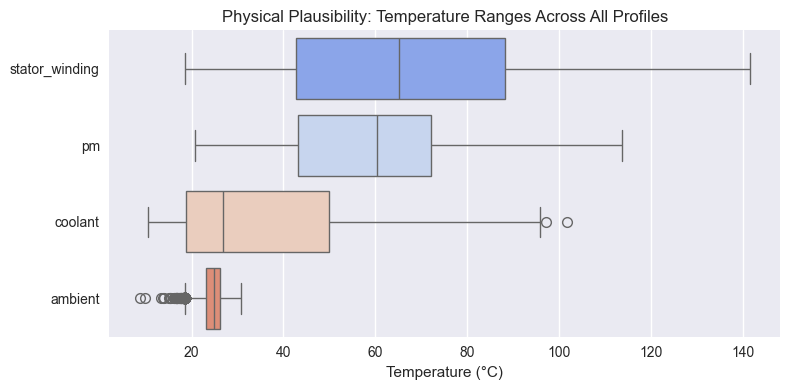

In [94]:
# Select core physical variables for the sanity check
cols_check = ["stator_winding", "pm", "coolant", "ambient", "motor_speed", "torque"]

# Avoid single-point measurement noise while accurately capturing the sustained operational boundaries.
temp_summary = df[cols_check].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(temp_summary)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[["stator_winding", "pm", "coolant", "ambient"]], orient="h", palette="coolwarm")
plt.title("Physical Plausibility: Temperature Ranges Across All Profiles")
plt.xlabel("Temperature (°C)")
plt.tight_layout()
plt.show()

---

## 7. Global Operating Envelope Characterization

To design robust feature engineering and normalization strategies, we compute the descriptive statistics defining the global operating envelope of the drive cycle:
* **Electrical bounds:** $u_{d,q}$ and $i_{d,q}$ limits dictate the inverter's maximum apparent power.
* **Mechanical bounds:** The `motor_speed` and `torque` percentiles define the mechanical phase space (including potential field-weakening regions).
* **Sensor validation:** Examining the 1st and 99th percentiles helps detect potential **sensor saturation or clipping** (where a signal artificially plateaus at a hardware limit).

,count,mean,std,min,1%,5%,50%,95%,99%,max
u_q,1330816.0,54.279005,44.173234,-25.290930,-2.204488,-0.927901,48.938181,130.151154,131.798141,133.036994
coolant,1330816.0,36.229995,21.786149,10.623751,18.033579,18.250466,26.900141,81.489642,91.092133,101.598512
stator_winding,1330816.0,66.342745,28.672061,18.585815,19.539682,22.050729,65.110129,115.178123,124.409470,141.362885
u_d,1330816.0,-25.133809,63.091972,-131.530411,-130.687167,-128.308578,-7.429755,98.147547,124.136306,131.469788
stator_tooth,1330816.0,56.878582,22.952233,18.133976,18.834770,21.397770,56.036345,93.765823,104.632818,111.946423
motor_speed,1330816.0,2202.080728,1859.663350,-275.549144,-0.004980,-0.001015,1999.976685,5499.943848,5999.934082,6000.015137
i_d,1330816.0,-68.716810,64.933233,-278.003632,-222.616927,-196.411500,-51.093763,-1.999848,-1.998214,0.051897
i_q,1330816.0,37.412782,92.181880,-293.426793,-216.182636,-130.093459,15.774007,188.412186,253.598892,301.707855
pm,1330816.0,58.506776,19.001498,20.856956,23.598197,28.131517,60.266287,89.355543,97.192052,113.606628
stator_yoke,1330816.0,48.187965,19.991004,18.076689,18.805664,19.850620,45.625509,85.165282,95.440674,101.147964


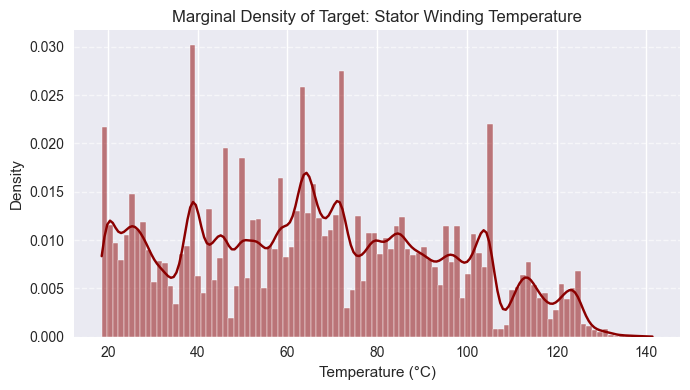

In [95]:
summary = df.drop(columns=["profile_id"]).describe(percentiles=[.01, .05, .5, .95, .99]).T
display(summary)

plt.figure(figsize=(7, 4))
sns.histplot(df["stator_winding"], bins=100, kde=True, stat="density", color="darkred")
plt.title("Marginal Density of Target: Stator Winding Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Density")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 7.1 Target Distribution Analysis

The marginal distribution of the `stator_winding` temperature is broad, strictly positive, and exhibits distinct multi-modal continuous density. 

**Physical Interpretation:**
These multiple peaks do not represent discrete categorical classes. Instead, they are the statistical footprint of the dynamometer test bench cycles. During testing, the motor is held at specific speed/torque setpoints to reach thermal equilibrium (steady-state). The peaks correspond to these equilibrium temperatures, while the density between the peaks represents the transient heating/cooling phases.

**Modeling Implication:**
The continuous nature of the target confirms the necessity of formulating this as a Regression Task. However, the multi-modality suggests that global error metrics (like overall MAE) might be heavily weighted towards these steady-state peaks. This reinforces the need for regime-aware evaluation and profile-specific validation in our downstream Machine Learning pipeline to ensure we accurately predict transients, not just the dense steady-state regions.

## 8. Electromechanical Operating Regimes (Four-Quadrant Analysis)

Extracting insights from the global percentiles reveals the operational complexity of the driving cycles:

* **Kinematic Range (`motor_speed`):** Spans approximately $0$ to $6000 \text{ rpm}$. The presence of slight negative minimums indicates occasional reverse rotation or measurement calibration artifacts.
* **Dynamic Load (`torque`):** Exhibits high variance, including deep negative values. Physically, this confirms that the drive operates in **four-quadrant mode**, executing both forward/reverse motoring and **regenerative braking** (acting as a generator). Note that Joule losses ($R \cdot i^2$) occur regardless of the power flow direction, contributing to heat generation even during braking.
* **Thermal Excursion (`stator_winding`):** Spans a massive $\approx 20^\circ\text{C}$ to $140^\circ\text{C}$.

**Conclusion:** The highly nonlinear relationship between mechanical power, regenerative phases, and the wide thermal span confirms that simple linear models will fail. Furthermore, the massive thermal amplitude implies a strong **thermal inertia** component that must be integrated into our modeling strategy (time-aware models).

Total Independent Profiles: 69
Samples per profile (Min / Median / Max): 2176 / 17142 / 43971


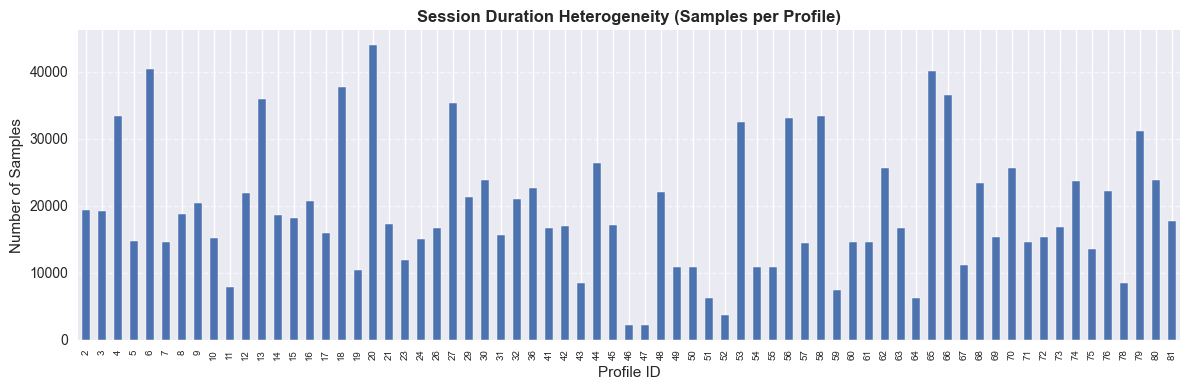

In [98]:
profile_sizes = df.groupby("profile_id").size().sort_index()

print(f"Total Independent Profiles: {df['profile_id'].nunique()}")
print(f"Samples per profile (Min / Median / Max): {int(profile_sizes.min())} / {int(profile_sizes.median())} / {int(profile_sizes.max())}")

# Visualization of session heterogeneity
ax = profile_sizes.plot(kind="bar", figsize=(12, 4), color="#4C72B0")
ax.set_title("Session Duration Heterogeneity (Samples per Profile)", fontweight="bold")
ax.set_xlabel("Profile ID")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis='x', labelsize=7)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 8.1 Session Heterogeneity & Temporal Sparsity

The dataset consists of 69 distinct driving sessions (`profile_id`), exhibiting extreme length heterogeneity: from $\sim 2,000$ to $\sim 44,000$ samples.

**Physical Time Translation:**
Given the sensor sampling rate of $2\text{ Hz}$ ($\Delta t = 0.5\text{s}$), we can translate these sample counts into actual physical test durations:
* **Shortest profiles:** $\approx 16 \text{ minutes}$. These capture rapid transient dynamics and localized thermal spikes.
* **Longest profiles:** $\approx 6.1 \text{ hours}$. These capture deep thermal soaking and slow steady-state equilibrium phases (e.g., heat dissipation through the motor yoke to the ambient environment).

> **Strategic Implication for Validation:**
> The model must generalize across both short dynamic bursts and long thermal saturation phases. Because each profile represents a unique, causally independent thermal trajectory, **any cross-validation strategy must split the data strictly by `profile_id` (e.g., GroupKFold)**. Standard random splitting would cause severe auto-correlation leakage, allowing the model to artificially interpolate adjacent timestamps rather than learning the underlying thermodynamic transfer function.

## 9. Inter-Session Variability & Thermal Initial Conditions

We now investigate how the target variable (`stator_winding`) behaves across different independent sessions. Since the motor's temperature at any time $t$ depends heavily on the heat accumulated prior to $t$, we must analyze the variance of the thermal states across the 69 profiles.

This step is critical to understand the diversity of the duty cycles and to quantify the risk of target shift (where the distribution of $y$ changes drastically between train and test sets).

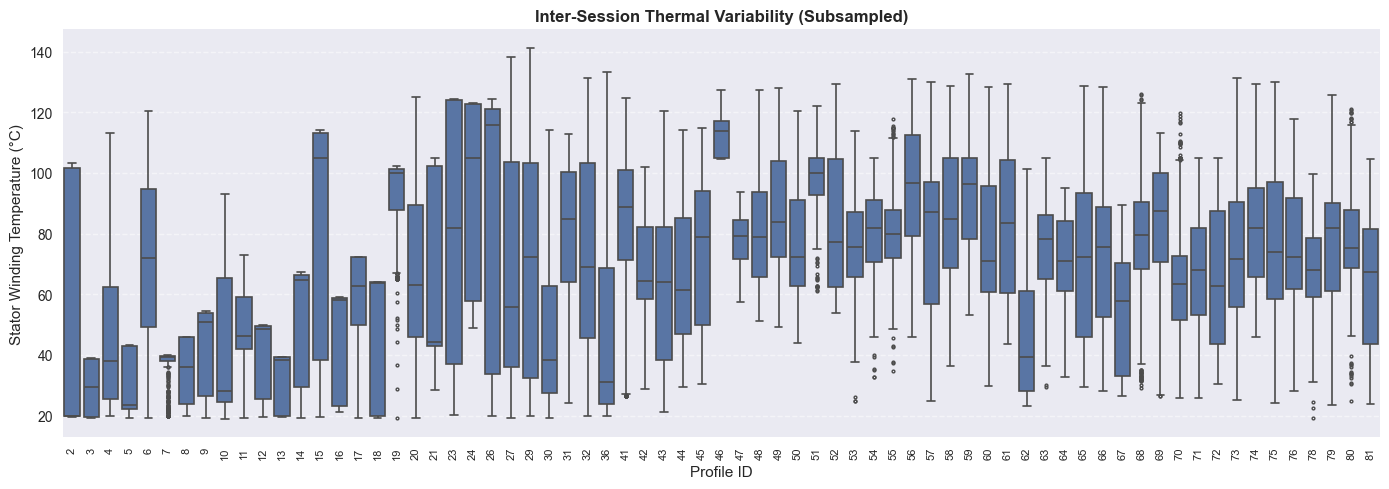

In [99]:
# Subsample the dataset for rendering efficiency while preserving the distribution topology
sampled = df.sample(n=50000, random_state=42)

plt.figure(figsize=(14, 5))
sns.boxplot(
    data=sampled,
    x="profile_id",
    y="stator_winding",
    color="#4C72B0",
    linewidth=1.2,
    fliersize=2
)
plt.title("Inter-Session Thermal Variability (Subsampled)", fontweight="bold")
plt.xlabel("Profile ID")
plt.ylabel("Stator Winding Temperature (°C)")
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 9.1 Physical Interpretation of Session Heterogeneity

The boxplot visualization reveals extreme topological variance in the thermal distributions across the 69 profiles. This is not random noise; it is the direct manifestation of distinct thermodynamic test procedures on the dynamometer:

1. **Initial Thermal States (Cold vs. Hot Starts):** Some profiles (e.g., Profile 20, 21) exhibit a median temperature well below 40°C, indicating a cold-started motor. Conversely, profiles like 46 or 65 operate almost exclusively above 80°C, indicating a pre-heated motor or a continuous heavy-load test.
2. **Duty Cycle Dynamics (Transient vs. Steady-State):** * **Narrow Interquartile Ranges (IQR)** (e.g., Profile 47, 62) suggest steady-state operations where the motor has reached thermal equilibrium (heat generation equals heat dissipation).
   * **Wide IQRs** (e.g., Profile 24, 69) indicate aggressive transient thermal cycling, pushing the motor from ambient conditions to near thermal limits.

### 9.2 Machine Learning Implications (OOD & Leakage)

This extreme inter-session heterogeneity definitively proves the necessity of our **Group-Aware Validation Strategy**. 

If we were to randomly split the data (e.g., standard `train_test_split`), the model would implicitly learn to map the specific combination of speed/torque to a specific profile's mean temperature, effectively "memorizing" the session rather than learning the generalized thermodynamic transfer function. 

By enforcing a strict `GroupKFold` on the `profile_id`, we force the model to handle Out-of-Distribution (OOD) thermal initial conditions, perfectly simulating the industrial reality of deploying a Soft-Sensor on a new vehicle or a new industrial machine.

## 10. Global Correlation Analysis: The Limits of Instantaneous Observation

We now compute the Pearson correlation matrix across all continuous numerical features. 

While correlation is a fundamental exploratory tool, it is crucial to interpret these global metrics through a thermodynamic lens. A standard correlation matrix measures instantaneous, linear relationships ($y_t$ vs. $x_t$). However, heat transfer is governed by differential equations, meaning the temperature at time $t$ is an integral of past power losses. Therefore, low instantaneous correlation does not necessarily imply low physical causality.

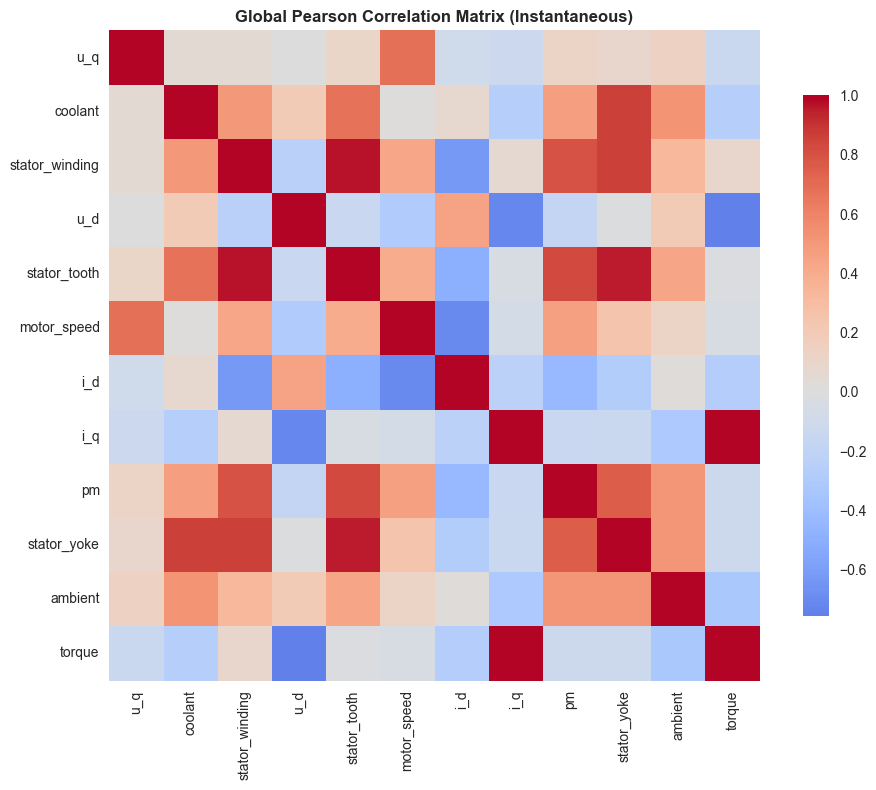

,Correlation with Target
stator_winding,1.000000
stator_tooth,0.970135
stator_yoke,0.860268
pm,0.795893
coolant,0.504835
motor_speed,0.432034
ambient,0.333208
torque,0.095510
i_q,0.065617
u_q,0.050610


In [100]:
# Extract numeric columns, explicitly excluding the categorical session identifier
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c != "profile_id"]

# Compute Pearson correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=False, # Set to True if you want exact values on the map
    cbar_kws={"shrink": 0.8}
)
plt.title("Global Pearson Correlation Matrix (Instantaneous)", fontweight="bold")
plt.tight_layout()
plt.show()

# Display correlations specifically with the target variable
display(corr["stator_winding"].sort_values(ascending=False).to_frame("Correlation with Target"))

### 10.1 Interpretation: Proximity vs. Causality

The correlation vector for `stator_winding` reveals a clear hierarchy based on spatial and thermal proximity rather than electrical causality:

1. **Strong Spatial Correlation (The Internal Temperatures):**
   * `stator_tooth` (0.970), `stator_yoke` (0.860), and `pm` (0.796) exhibit massive correlation. This is physically intuitive: they are adjacent metallic masses within the same motor housing. Heat diffuses conductively between them, meaning their temperatures rise and fall together.
   * *Strategic Decision:* Despite their predictive power, these variables are **strictly excluded** from our feature set. In a real-world scenario, if you cannot measure the winding, you almost certainly cannot measure the tooth or the permanent magnets. Using them would constitute a form of target leakage.

2. **Moderate Environmental Correlation:**
   * `coolant` (0.505) and `ambient` (0.333) show moderate positive correlation. The coolant dictates the baseline thermal state of the system; a hotter coolant means a hotter motor baseline.

3. **Weak Instantaneous Electrical Correlation (The Inertia Trap):**
   * Variables like `torque` (0.095), `i_q` (0.065), and `u_q` (0.050) show near-zero instantaneous correlation. 
   * *Engineering Insight:* It would be a severe analytical error to discard these features. $i_q$ (current) generates Joule losses ($P \propto i^2$), and $u_q$ (voltage) relates to active power. The correlation is low only because of **thermal inertia**: a spike in current causes an immediate spike in heat *generation*, but the actual *temperature* rises slowly over the following seconds or minutes.

**Conclusion:** This global view confirms that static, instantaneous models (like standard Linear Regression) will fail to capture the underlying physics. We must transition to **time-aware feature engineering** (e.g., rolling windows, lagged variables) or **Deep Sequential Learning** to align our model with the thermodynamic reality of the motor.

## 11. Time-Series Analysis: Transient Dynamics and Thermal Inertia

To move beyond aggregated statistics, we must observe the temporal behavior of the motor during a continuous driving cycle. 

We select the longest continuous session in the dataset (Profile 20, spanning $>6$ hours) to visualize the full spectrum of thermal dynamics, from rapid transients to slow thermal saturation (heat soaking). 
> Note that the dataset is sampled at **2 Hz**; the x-axis is explicitly converted to seconds to ground the observation in physical time.

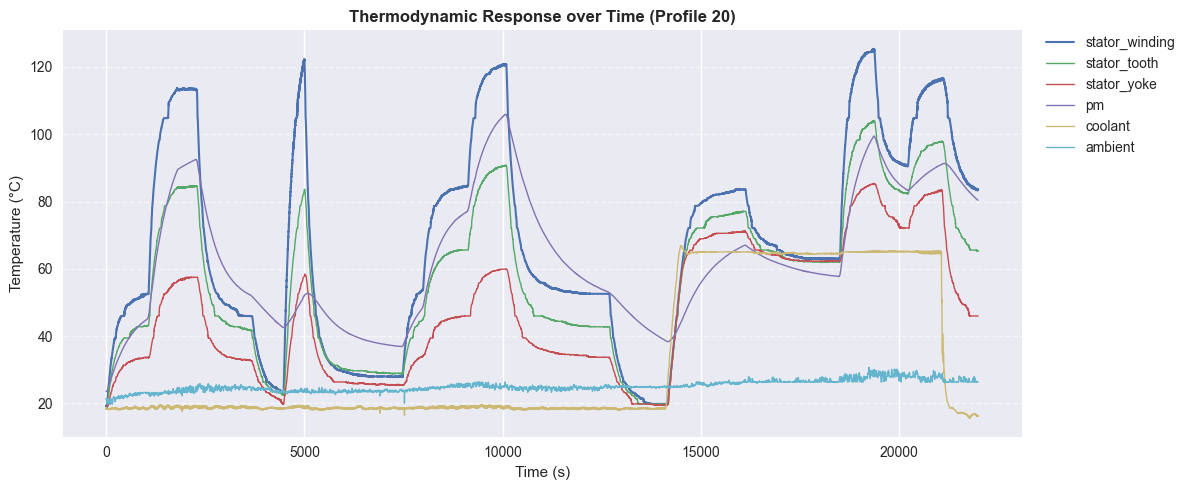

In [101]:
FS_HZ = 2.0

pid = df.profile_id.value_counts().idxmax()
sub = df[df.profile_id == pid]

t = np.arange(len(sub)) / FS_HZ

plt.figure(figsize=(12, 5))
for c in ["stator_winding", "stator_tooth", "stator_yoke", "pm", "coolant", "ambient"]:
    plt.plot(t, sub[c].to_numpy(), label=c, linewidth=1.5 if c == "stator_winding" else 1.0)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.title(f"Thermodynamic Response over Time (Profile {pid})", fontweight="bold")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 11.1 The Thermal Low-Pass Filter Effect

The temperature plot perfectly illustrates the physical realities of heat transfer:
1. **Asymptotic Exponential Response:** When a load is applied, the temperatures do not spike instantly. They rise logarithmically toward a steady-state asymptote. When the load is removed, they decay exponentially. This behavior is mathematically identical to an RC (Resistor-Capacitor) circuit or a **First-Order Low-Pass Filter**.
2. **Multiple Time Constants ($\tau$):** 
   * The `stator_winding` (blue line) reacts fastest and reaches the highest peaks. Copper generates the heat (Joule effect) and has a relatively low thermal mass.
   * The `stator_yoke` (red line) reacts much slower and acts as a thermal buffer. It is a massive block of iron with high thermal capacitance.


To understand *what* is driving these thermal responses, we must overlay the electromechanical inputs.

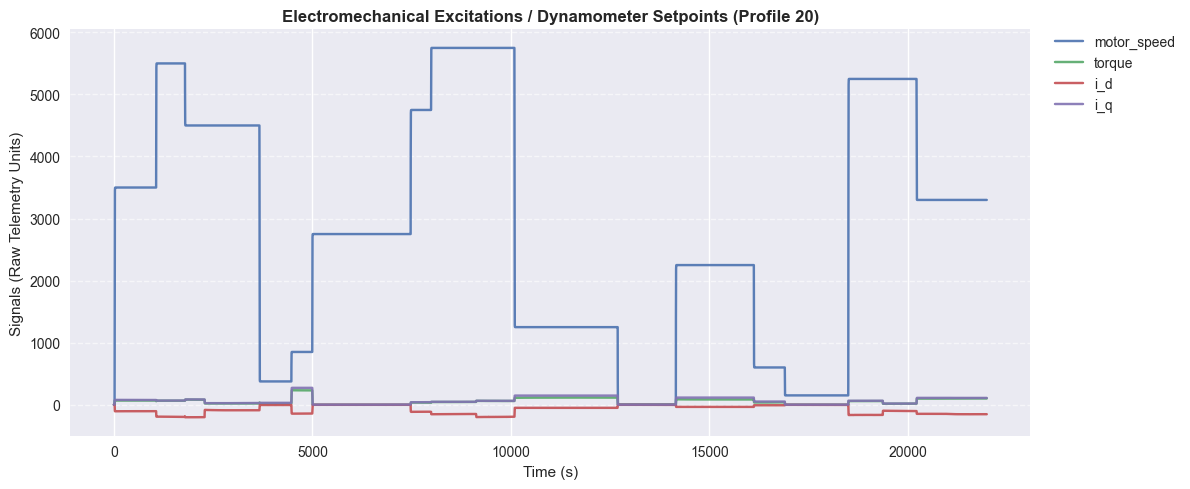

In [102]:
plt.figure(figsize=(12, 5))
for c in ["motor_speed", "torque", "i_d", "i_q"]:
    plt.plot(t, sub[c].to_numpy(), label=c, alpha=0.9)

plt.title(f"Electromechanical Excitations / Dynamometer Setpoints (Profile {pid})", fontweight="bold")
plt.xlabel("Time (s)")
plt.ylabel("Signals (Raw Telemetry Units)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 11.2 The Causal Chain & Modeling Justification

Comparing the two plots exposes the fundamental challenge of this dataset:
* **The Excitations (Inputs):** The electrical and mechanical signals (`motor_speed`, `torque`, $i_q$) are piecewise-constant. They look like sharp "step functions" dictated by the dynamometer's test protocol.
* **The Response (Output):** The temperatures are smooth, continuous, and delayed.

**The Machine Learning Conundrum:**
If a standard static model (like a simple Neural Network or Random Forest) observes the system at $t = 5000\text{s}$, it sees $i_q \approx 0$ and $\text{torque} \approx 0$. A static model will instantly predict a cold motor. However, the upper plot shows the motor is still dissipating heat and sits at over 100°C due to the massive load applied at $t = 4000\text{s}$.

**Conclusion of the EDA:**
The strict physical causal chain (Electrical Load $\rightarrow$ Heat Generation $\rightarrow$ Thermal Diffusion / Accumulation) completely invalidates memory-less models. To achieve industrial-grade accuracy, our modeling strategy **must** incorporate time. This perfectly justifies our dual approach for the next stages:
1. **Feature Engineering Track:** Creating explicit rolling memory features (moving averages, lagged gradients) to feed tabular models.
2. **Deep Learning Track:** Utilizing Recurrent Neural Networks (like GRUs) to let an algorithm natively learn the motor's latent thermal state and time constants.

---

## 12. Electromechanical Phase Space (The Motor Envelope)

To fully grasp the diversity of the dataset, we map every strictly sampled timestamp onto the Speed-Torque plane. In electric motor design, this mapping is known as the operating envelope or *Motor Capability Curve*.

This visualization acts as a spatial fingerprint of the driving cycles, highlighting the operational boundaries (Continuous vs. Peak torque limits) and the transition into the Field Weakening region (where maximum torque naturally decays at high speeds).

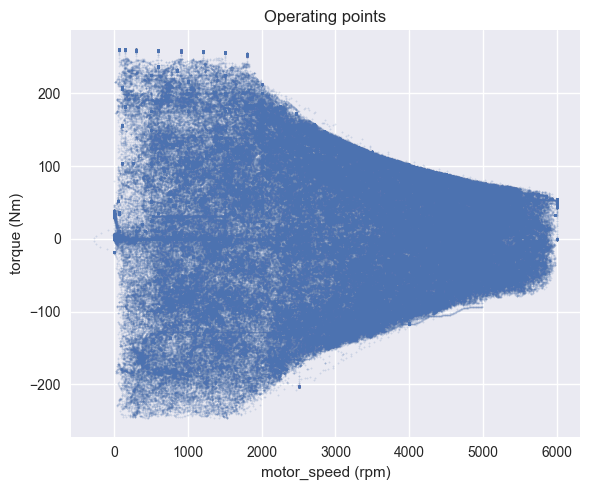

In [87]:
plt.figure(figsize=(6,5))
plt.scatter(df["motor_speed"], df["torque"], s=1, alpha=0.15)
plt.xlabel("motor_speed (rpm)")
plt.ylabel("torque (Nm)")
plt.title("Operating points")
plt.tight_layout()
plt.show()

### 12.1 Interpretation of the Envelope
The resulting map demonstrates extreme operational diversity:
1. **Four-Quadrant Operation:** Heavy density in both positive (motoring) and negative (generating/braking) torque regions.
2. **Boundary Limits:** The visible perimeter defines the physical constraints of the inverter/motor pairing.
3. **Machine Learning Implication:** A Soft-Sensor must remain robust across this entire phase space. A model trained only on low-speed/high-torque data will fail catastrophically in the high-speed/low-torque field-weakening regime where iron losses dominate copper losses.

---

## 13. The Hysteresis Trap: Instantaneous Power vs. Temperature

As a final proof of the necessity for sequence modeling, we synthesize the electrical signals into a proxy for **Active Power**, governed by the $d-q$ frame equation:
$$P_{active} \propto u_d \cdot i_d + u_q \cdot i_q$$

We then plot this instantaneous heat source against the target temperature.

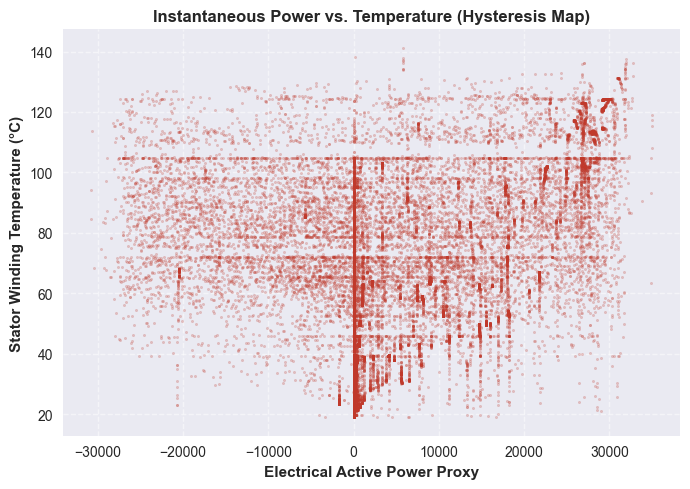

In [ ]:
# Compute active electrical power proxy (ignoring the 3/2 constant factor)
power_proxy = df["u_d"] * df["i_d"] + df["u_q"] * df["i_q"]

# Subsample to avoid severe overplotting and memory overload
sampled = df.sample(n=30000, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(
    power_proxy.loc[sampled.index],
    sampled["stator_winding"],
    s=3,
    alpha=0.25,
    color="#C0392B"
)
plt.xlabel("Electrical Active Power Proxy", fontweight="bold")
plt.ylabel("Stator Winding Temperature (°C)", fontweight="bold")
plt.title("Instantaneous Power vs. Temperature (Hysteresis Map)", fontweight="bold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 13.1 Why Memory-Less Models Fail

Looking at the scatter plot, there is **no clear instantaneous bijection** (1-to-1 mapping) between the power being injected and the stator temperature. Instead, we observe a massive, dispersed cloud.

This dispersion is not measurement noise; it is the physical manifestation of **Thermal Hysteresis**. 
For a single power state (e.g., $P = 0$), the stator can be at 20°C (if the motor has been resting) or at 130°C (if the motor has just finished a severe load cycle and is slowly cooling down). 

---

## 14. Empirical Estimation of Thermal Inertia (Cross-Correlation)

While we have established that thermal inertia exists, we need to quantify its order of magnitude to inform our modeling decisions—specifically, the size of rolling windows for tabular models and the sequence length ($W$) for recurrent architectures.

We can estimate the **effective thermal time constant ($\tau$)** by computing the cross-correlation between the instantaneous active power proxy ($P_{active}$) and the target temperature (`stator_winding`) across various time lags. The lag that maximizes this correlation represents the average delay between heat generation and the observable temperature peak at the sensor.

$$P_{active}(t-\Delta t) \propto u_d(t-\Delta t) \cdot i_d(t-\Delta t) + u_q(t-\Delta t) \cdot i_q(t-\Delta t)$$

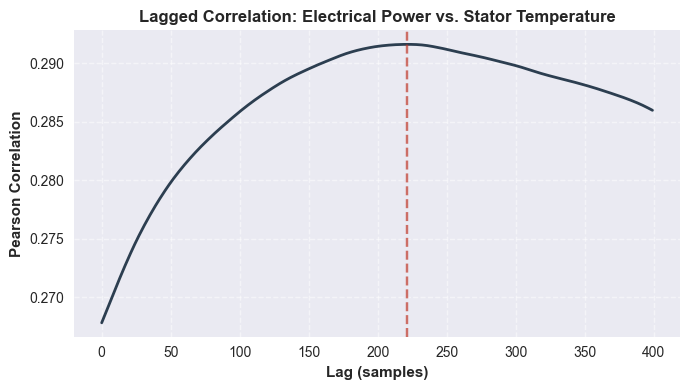

Optimal Lag: 221 samples (~110.5 seconds at 2.0 Hz)
Peak Correlation: 0.292


In [104]:
# Compute active electrical power proxy
power = df["u_d"] * df["i_d"] + df["u_q"] * df["i_q"]

# Evaluate lags up to 400 samples (200 seconds)
lags = np.arange(0, 400)
corrs = np.empty_like(lags, dtype=float)

# Compute lagged Pearson correlation
for i, l in enumerate(lags):
    p = power.shift(l)
    mask = p.notna()
    corrs[i] = np.corrcoef(p[mask], df.loc[mask, "stator_winding"])[0, 1]

# Visualization
plt.figure(figsize=(7, 4))
plt.plot(lags, corrs, color="#2C3E50", linewidth=2)
plt.axvline(lags[np.nanargmax(corrs)], color="#C0392B", linestyle="--", alpha=0.7)
plt.xlabel("Lag (samples)", fontweight="bold")
plt.ylabel("Pearson Correlation", fontweight="bold")
plt.title("Lagged Correlation: Electrical Power vs. Stator Temperature", fontweight="bold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Extract optimal lag
best_lag = lags[int(np.nanargmax(corrs))]
best_corr = float(np.nanmax(corrs))

FS_HZ = 2.0
print(f"Optimal Lag: {best_lag} samples (~{best_lag/FS_HZ:.1f} seconds at {FS_HZ:.1f} Hz)")
print(f"Peak Correlation: {best_corr:.3f}")

### 14.1 Interpretation and Modeling Strategy

The cross-correlation analysis yields a peak at **$\approx 110$ seconds** (221 samples).

**Engineering Insight:**
This value provides an empirical estimate of the stator winding's dominant thermal time constant ($\tau$) under varied load conditions. It mathematically confirms that instantaneous electrical measurements are poor direct predictors of temperature, as their maximum predictive power occurs nearly two minutes after the event.

**Strategic Implications for Modeling:**
1. **Feature Engineering:** We must construct rolling statistical windows (e.g., moving averages, cumulative sums) that span at least this 110-second horizon to capture the necessary thermal history for tabular models (like HistGB).
2. **Deep Sequence Modeling:** This explicitly justifies designing our Recurrent Neural Network (GRU) with a historical window ($W$) that encompasses this delay. A window of $W=300$ samples (150 seconds) is physically appropriate to capture the full transient dynamic leading up to the current temperature state.

> **Methodological Note:**
> This lag analysis was computed globally across concatenated profiles for exploratory purposes. While boundary effects (profile transitions) introduce minor noise, the sheer volume of data ensures the order-of-magnitude estimate ($\approx 2$ minutes) remains robust. In subsequent modeling phases, all temporal operations (rolling windows, sequence generation) will strictly respect `profile_id` boundaries.

## 15. Information-Theoretic Analysis: Capturing Non-Linear Dependencies

The Pearson correlation matrix previously demonstrated that linear, instantaneous relationships between electrical inputs and temperature are weak. However, thermodynamic interactions in electric drives are fundamentally non-linear (e.g., Joule heating scales with $i^2$, and convective cooling efficiency scales non-linearly with $\omega$).

To quantify these non-linear associations, we utilize *Mutual Information (MI)* from Information Theory. MI measures the reduction in uncertainty (Shannon entropy) about the target variable given the knowledge of a feature, capturing any kind of dependency (linear or non-linear).

,Mutual Information Score
stator_tooth,2.590707
stator_yoke,2.247204
pm,1.824635
u_q,1.799003
u_d,1.754966
torque,1.654726
i_d,1.280639
i_q,1.274017
motor_speed,1.081898
coolant,0.998382


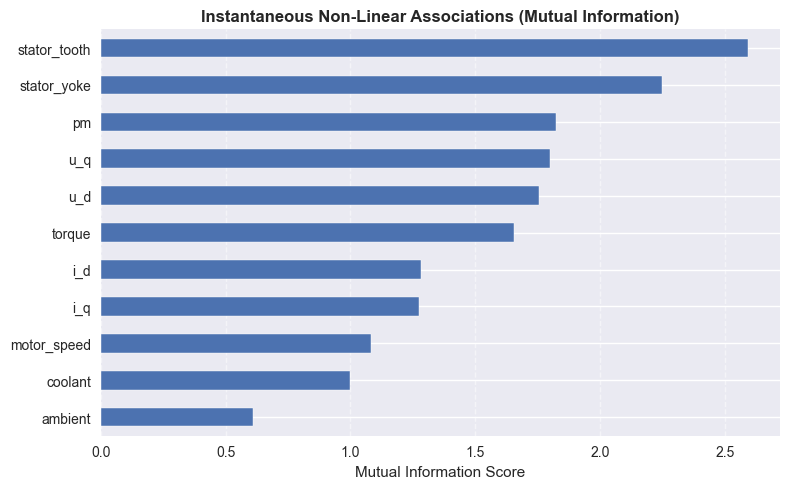

In [106]:
X = df.drop(columns=["stator_winding", "profile_id"])
y = df["stator_winding"]

mi_vals = mutual_info_regression(X, y, random_state=42)
mi_s = pd.Series(mi_vals, index=X.columns).sort_values(ascending=False)

display(mi_s.to_frame("Mutual Information Score"))

plt.figure(figsize=(8, 5))
mi_s.sort_values(ascending=True).plot(kind="barh", color="#4C72B0")
plt.title("Instantaneous Non-Linear Associations (Mutual Information)", fontweight="bold")
plt.xlabel("Mutual Information Score")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 15.1 Interpretation: The Non-Linear Revelation

Comparing these Mutual Information (MI) scores with the previous Pearson correlation yields a critical engineering insight:
* **The Hidden Electrical Signal:** In the linear analysis, voltages ($u_d$, $u_q$) and $torque$ showed near-zero correlation ($< 0.1$). However, in the MI ranking, they surge past $1.6$, outranking both `motor_speed` and `coolant`. 
* **Physical Implication:** This proves that the instantaneous electrical state *does* contain massive amounts of information about the thermal state. However, because heat generation relies on quadratic principles (e.g., Joule heating $\propto i^2$) and is temporally delayed, this information is embedded in a highly non-linear manifold that linear metrics fail to capture.

---

## 16. Executive Summary & Modeling Implications

This Exploratory Data Analysis formally establishes the physical and statistical constraints of our system. Predicting the stator winding temperature emerges fundamentally as a **long-memory response to electromechanical load**, rather than an instantaneous mapping of inputs.

To build an industrial-grade Soft-Sensor, our downstream Machine Learning pipeline must respect the following core conclusions:

1. **The Soft-Sensor Boundary Constraint:** Internal temperatures (`stator_tooth`, `stator_yoke`, `pm`) are highly informative due to spatial thermal diffusion. However, since they are generally unavailable in a realistic production scenario, they must be **strictly excluded** from the main feature set to prevent target leakage.
2. **The Thermodynamic Memory (Inertia):** The cross-correlation analysis reveals that the power-temperature relationship peaks at a significant delay ($\approx 110\text{s}$ at $2\text{ Hz}$). This confirms that predicting temperature strictly from instantaneous state variables ($X_t \rightarrow Y_t$) is mathematically ill-posed. The model must integrate long-horizon temporal features.
3. **Cross-Session Heterogeneity & Validation Rigor:** The motor operates across a highly heterogeneous speed-torque envelope, with session durations ranging from 16 minutes to over 6 hours. Furthermore, varying initial conditions (cold vs. hot starts) mean that each profile is a unique, causally independent trajectory. Therefore, **strict group-aware validation (split by `profile_id`) is mandatory** to prevent auto-correlation leakage and ensure Out-Of-Distribution (OOD) robustness.
4. **Non-Linear Dependency:** The electrical signals act indirectly. Their instantaneous associations with temperature are non-linear, consistent with energy accumulation laws, demanding the use of complex, non-linear algorithms (Tree-based or Deep Learning architectures).

---

## 17. Modeling Roadmap & Next Steps

To translate these physical insights into robust Machine Learning inputs, the project will proceed as follows:

* **Notebook 02 (Feature Engineering):** We will manually construct the thermal memory using physically motivated, leakage-safe features. This includes:
  * Rolling statistics (mean, std) over windows aligned with the identified thermal time scales ($\approx 110\text{s}$).
  * Active electrical power and cumulative energy proxies.
  * Temporal gradients (first-order differences) to capture rapid transients.
* **Notebooks 04 & 05 (Machine Learning):** We will deploy non-linear architectures capable of handling these dynamics. We will first establish a rigorous baseline using **Tabular Gradient Boosting (HistGB)** on our engineered features, and subsequently introduce **Deep Sequential Learning (GRU)** to allow the network to natively learn the thermal time constants and latent heat states.